# LIVEDET — Real-Time Pipeline Benchmark

This notebook benchmarks the combined YOLO11s and MiDaS Small inference pipeline on a test video, measuring performance under standard conditions. It tracks preprocessing, YOLO inference, MiDaS depth mapping, and postprocessing latency.

In [1]:
import os
import sys
import time
import csv
import base64
import numpy as np
import torch
import cv2
import pandas as pd
import matplotlib.pyplot as plt

# Add workspace root to system path to import backend components
workspace_root = os.path.abspath('..')
sys.path.append(workspace_root)

from backend.detector import ObjectDetector
from backend.utils import (
    DepthEstimator,
    extract_median_depth,
    compute_depth_cm,
    compute_heuristic_measurements,
    compute_midas_confidence,
    blend_depth,
    compute_real_width,
    classify_severity
)
from backend.config import Config

INFO:Detector:Ultralytics YOLO module loaded
INFO:backend.config:Loaded configuration from c:\Users\ihsan\Documents\GitHub\ML2\.env


In [2]:
# Load configuration and setup device
cfg = Config(env_file=os.path.join(workspace_root, '.env'))
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Device in use: {device}")
if device.startswith("cuda"):
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

model_path = os.path.join(workspace_root, cfg.BEST_MODEL_PATH.lstrip('./'))
print(f"Using YOLO model: {model_path}")

INFO:backend.config:Loaded configuration from c:\Users\ihsan\Documents\GitHub\ML2\.env


Device in use: cuda:0
GPU Name: NVIDIA GeForce GTX 1650
Using YOLO model: c:\Users\ihsan\Documents\GitHub\ML2\models/finetuned/pothole_detector_yolo11s_v22/weights/best.pt


In [3]:
# Initialize detectors
confidence_threshold = getattr(cfg, "CONFIDENCE_THRESHOLD", 0.15)
iou_threshold = getattr(cfg, "IOU_THRESHOLD", 0.25)
focal_length = 600.0

detector = ObjectDetector(
    model_path=model_path, 
    device=device, 
    confidence_threshold=confidence_threshold, 
    iou_threshold=iou_threshold
)

depth_estimator = DepthEstimator(device=device)
if depth_estimator.initialized:
    print("MiDaS Depth Estimator initialized successfully.")
else:
    print("Error: MiDaS failed to initialize.")

INFO:Detector:Loading model path: c:\Users\ihsan\Documents\GitHub\ML2\models/finetuned/pothole_detector_yolo11s_v22/weights/best.pt
INFO:Detector:Model loaded successfully
INFO:backend.utils:[MiDaS] Loading MiDaS_small on cuda:0...
Using cache found in C:\Users\ihsan/.cache\torch\hub\intel-isl_MiDaS_master


Loading weights:  None


Using cache found in C:\Users\ihsan/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master
Using cache found in C:\Users\ihsan/.cache\torch\hub\intel-isl_MiDaS_master
INFO:backend.utils:[MiDaS] ✓ Depth model ready


MiDaS Depth Estimator initialized successfully.


In [4]:
# Warm up the model to avoid initial latency spikes
print("Warming up models...")
dummy = np.zeros((480, 640, 3), dtype=np.uint8)
for _ in range(10):
    _ = detector.model(dummy, conf=confidence_threshold, iou=iou_threshold, device=device, verbose=False)
    _ = depth_estimator.estimate(dummy)
if device.startswith("cuda"):
    torch.cuda.synchronize()
print("Warm-up complete.")

Warming up models...
Warm-up complete.


In [5]:
# Open the test video
video_path = os.path.join(workspace_root, "frontend", "public", "videos", "video_demo.mp4")
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print(f"Error opening video file: {video_path}")
else:
    print(f"Successfully opened: {video_path}")

Successfully opened: c:\Users\ihsan\Documents\GitHub\ML2\frontend\public\videos\video_demo.mp4


In [6]:
# Run benchmark
max_frames = 300
frame_records = []
frame_id = 0

print(f"Processing {max_frames} frames...")
while frame_id < max_frames:
    ret, frame_bgr = cap.read()
    if not ret:
        cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
        ret, frame_bgr = cap.read()
        if not ret:
            print("Failed to loop video.")
            break
            
    frame_id += 1
    
    # Preprocess
    _, buffer = cv2.imencode('.jpg', frame_bgr)
    b64_str = base64.b64encode(buffer)
    t_pre_start = time.perf_counter()
    img_bytes = base64.b64decode(b64_str)
    arr = np.frombuffer(img_bytes, dtype=np.uint8)
    decoded_frame = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    frame_rgb = cv2.cvtColor(decoded_frame, cv2.COLOR_BGR2RGB)
    fh, fw = decoded_frame.shape[:2]
    t_pre_end = time.perf_counter()
    preprocess_ms = (t_pre_end - t_pre_start) * 1000.0
    
    # YOLO Inference
    if device.startswith("cuda"):
        torch.cuda.synchronize()
    t_yolo_start = time.perf_counter()
    results = detector.model(frame_rgb, conf=confidence_threshold, iou=iou_threshold, device=device, verbose=False)
    if device.startswith("cuda"):
        torch.cuda.synchronize()
    t_yolo_end = time.perf_counter()
    yolo_ms = (t_yolo_end - t_yolo_start) * 1000.0
    
    # MiDaS Depth
    if device.startswith("cuda"):
        torch.cuda.synchronize()
    t_midas_start = time.perf_counter()
    cached_depth = depth_estimator.estimate(frame_rgb)
    if device.startswith("cuda"):
        torch.cuda.synchronize()
    t_midas_end = time.perf_counter()
    midas_ms = (t_midas_end - t_midas_start) * 1000.0
    
    # Postprocess
    t_post_start = time.perf_counter()
    detections = []
    for result in results:
        if result.boxes is not None:
            for box in result.boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                conf = float(box.conf[0])
                cls_id = int(box.cls[0])
                cls_name = detector.model.names.get(cls_id, f"class_{cls_id}")
                if cls_name.lower() in ["plain", "pothole", "pot"]:
                    cls_name = "Pothole"
                detections.append({
                    "bbox": [int(x1), int(y1), int(x2 - x1), int(y2 - y1)],
                    "bbox_xyxy": [float(x1), float(y1), float(x2), float(y2)],
                    "confidence": conf,
                    "class_id": cls_id,
                    "class_name": cls_name
                })
                
    det_out = []
    for det in detections:
        x, y, w, h = det["bbox"]
        conf       = det["confidence"]
        if cached_depth is not None:
            med = extract_median_depth(cached_depth, (x, y, w, h))
            midas_depth_cm = compute_depth_cm(med)
            heuristic = compute_heuristic_measurements((x, y, w, h), (fh, fw))
            midas_conf = compute_midas_confidence(cached_depth, (x, y, w, h))
            depth_cm = blend_depth(midas_depth_cm, heuristic["depth_cm"], midas_conf)
            width_cm  = compute_real_width(float(w), med, focal_length)
        else:
            heuristic = compute_heuristic_measurements((x, y, w, h), (fh, fw))
            depth_cm  = heuristic["depth_cm"]
            width_cm  = heuristic["width_cm"]
            
        severity_label, severity_score = classify_severity(depth_cm, width_cm, conf)
        
    _ = detector.annotate_image(decoded_frame, detections)
    t_post_end = time.perf_counter()
    postprocess_ms = (t_post_end - t_post_start) * 1000.0
    
    # Total & FPS
    total_ms = preprocess_ms + yolo_ms + midas_ms + postprocess_ms
    fps = 1000.0 / total_ms if total_ms > 0 else 0.0
    
    frame_records.append([
        frame_id, preprocess_ms, yolo_ms, midas_ms, postprocess_ms, total_ms, fps
    ])

cap.release()
print("Benchmark complete.")

Processing 300 frames...
Benchmark complete.


In [7]:
# Export files
csv_headers = ["frame_id", "preprocess_ms", "yolo_inference_ms", "midas_depth_ms", "postprocess_ms", "total_latency_ms", "fps"]
df = pd.DataFrame(frame_records, columns=csv_headers)
# Ensure directory exists
output_dir = os.path.join(workspace_root, "notebooks", "results", "results_04")
os.makedirs(output_dir, exist_ok=True)
df.to_csv(os.path.join(output_dir, "benchmark_timeseries.csv"), index=False)
print("Saved benchmark_timeseries.csv to results_04")

Saved benchmark_timeseries.csv to results_04


In [8]:
# Calculate Summary Metrics
latencies = df["total_latency_ms"]
fps_values = df["fps"]

mean_latency = latencies.mean()
median_latency = latencies.median()
min_latency = latencies.min()
max_latency = latencies.max()
std_latency = latencies.std()
p95_latency = np.percentile(latencies, 95)
mean_fps = fps_values.mean()

under_40_pct = (latencies < 40.0).mean() * 100.0
above_40_pct = (latencies >= 40.0).mean() * 100.0

summary = f"""LIVEDET Pipeline Benchmark Summary
=============================================
Total Frames: {len(df)}
Device: {device} ({torch.cuda.get_device_name(0) if device.startswith('cuda') else 'CPU'})

Latency Metrics (ms):
  Mean:            {mean_latency:.3f} ms
  Median:          {median_latency:.3f} ms
  Min:             {min_latency:.3f} ms
  Max:             {max_latency:.3f} ms
  Std Dev:         {std_latency:.3f} ms
  95th Percentile: {p95_latency:.3f} ms

FPS Metrics:
  Average FPS:     {mean_fps:.2f} FPS

Target Compliance (40 ms threshold):
  Under 40 ms:     {under_40_pct:.2f}%
  Above 40 ms:     {above_40_pct:.2f}%
"""
print(summary)

LIVEDET Pipeline Benchmark Summary
Total Frames: 300
Device: cuda:0 (NVIDIA GeForce GTX 1650)

Latency Metrics (ms):
  Mean:            109.236 ms
  Median:          99.517 ms
  Min:             89.543 ms
  Max:             429.606 ms
  Std Dev:         29.804 ms
  95th Percentile: 158.466 ms

FPS Metrics:
  Average FPS:     9.51 FPS

Target Compliance (40 ms threshold):
  Under 40 ms:     0.00%
  Above 40 ms:     100.00%



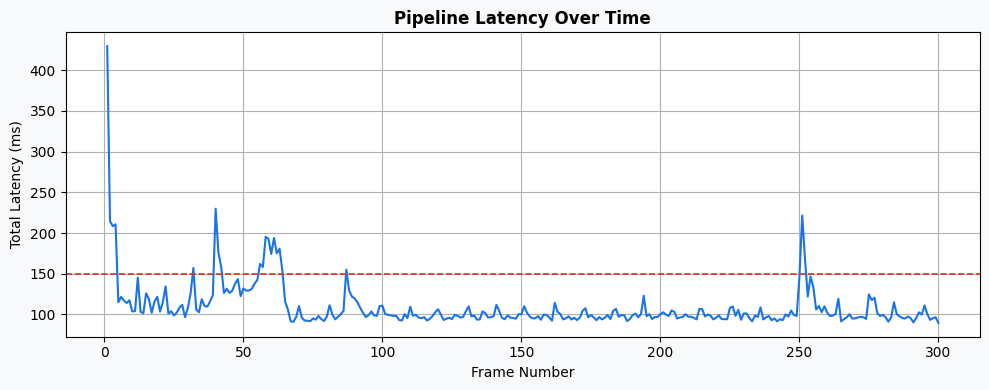

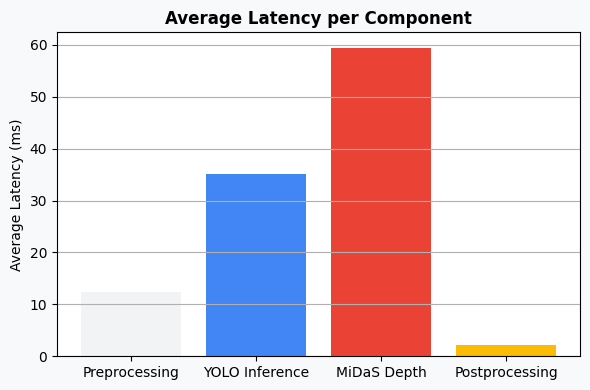

In [14]:
# Plot Visualizations
plt.rcParams.update({
    'font.family': 'sans-serif',
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor': '#FFFFFF'
})

output_dir = os.path.join(workspace_root, "notebooks", "results", "results_04")
os.makedirs(output_dir, exist_ok=True)

# 1. Latency Plot
plt.figure(figsize=(10, 4))
plt.plot(df["frame_id"], df["total_latency_ms"], color="#1A73E8", linewidth=1.5)
plt.axhline(y=150.0, color="#D93025", linestyle="--", linewidth=1.2)
plt.title("Pipeline Latency Over Time", fontsize=12, fontweight="bold")
plt.xlabel("Frame Number")
plt.ylabel("Total Latency (ms)")
plt.grid(True)
plt.tight_layout()
timeseries_path = os.path.join(output_dir, "pipeline_latency_timeseries.png")
plt.savefig(timeseries_path, dpi=300)
plt.show()
print(f"Saved timeseries plot to {timeseries_path}")

# 2. Component breakdown
components = ['Preprocessing', 'YOLO Inference', 'MiDaS Depth', 'Postprocessing']
averages = [
    df['preprocess_ms'].mean(),
    df['yolo_inference_ms'].mean(),
    df['midas_depth_ms'].mean(),
    df['postprocess_ms'].mean()
]
plt.figure(figsize=(6, 4))
plt.bar(components, averages, color=['#F1F3F4', '#4285F4', '#EA4335', '#FBBC05'])
plt.title("Average Latency per Component", fontsize=12, fontweight="bold")
plt.ylabel("Average Latency (ms)")
plt.grid(axis='y')
plt.tight_layout()
bar_chart_path = os.path.join(output_dir, "average_component_latency.png")
plt.savefig(bar_chart_path, dpi=300)
plt.show()
print(f"Saved bar chart to {bar_chart_path}")
